In [1]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import lightning.pytorch as pl
from lightning.pytorch.callbacks import RichProgressBar, Timer, LearningRateFinder
import omegaconf


# Add the prime_torch file to the system path so we can import it
import sys
sys.path.append("/glade/u/home/cobrien/prime/prime_lib/primesw")
from data import SWDataset, SWDataModule
from prime_torch import crps, SWRegressor

In [2]:
torch.set_float32_matmul_precision('medium')


# Load the Geotail (strict) model (handles density and ion temperature)
geo_config = '/glade/u/home/cobrien/prime/prime_lib/configs/plasmasheet_stricttemp.yaml'
geo_cfg = omegaconf.OmegaConf.load(
    geo_config
)
geo_model = SWRegressor.load_from_checkpoint(
    "/glade/u/home/cobrien/data/prime/tensorboard_logs/psstrict/version_1/checkpoints/epoch=199-step=11000.ckpt"
)
geo_model.eval() # Freeze the model

# Load the MMS model (handles ion temperature, electron temperature, and their ratio)
mms_config = '/glade/u/home/cobrien/prime/prime_lib/configs/plasmasheet_mmstemp.yaml'
mms_cfg = omegaconf.OmegaConf.load(
    mms_config
)
mms_model = SWRegressor.load_from_checkpoint(
    "/glade/u/home/cobrien/data/prime/tensorboard_logs/psmms/version_2/checkpoints/epoch=199-step=1600.ckpt"
)
mms_model.eval() # Freeze the model

/glade/work/cobrien/conda-envs/pt212gpu_conda/lib/python3.11/site-packages/torch/cuda/__init__.py:611: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


SWRegressor(
  (trn_mae): ProbabilisticMeanAbsoluteError()
  (val_mae): ProbabilisticMeanAbsoluteError()
  (tst_mae): ProbabilisticMeanAbsoluteError()
  (encoder): RecurrentEncoder(
    (network): RNN(14, 256, num_layers=2, batch_first=True, dropout=0.2)
  )
  (decoder): LinearDecoder(
    (network): Sequential(
      (0): Linear(in_features=268, out_features=256, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.2, inplace=False)
      (3): Linear(in_features=256, out_features=128, bias=True)
      (4): ReLU()
      (5): Dropout(p=0.2, inplace=False)
      (6): Linear(in_features=128, out_features=64, bias=True)
      (7): ReLU()
      (8): Dropout(p=0.2, inplace=False)
      (9): Linear(in_features=64, out_features=6, bias=True)
    )
  )
)

In [3]:
# Load the data
wind_data = pd.read_hdf('/glade/u/home/cobrien/data/magnetotail/resampled_datasets.h5', key = 'wind_full', mode = 'r')

# Cut the input wind data to just the interval covered by the themis data
bounds = [
    pd.to_datetime("20220819 05:45:00+0000"), #Start
    pd.to_datetime("20220819 07:15:00+0000"), #Stop
]
wind_data = wind_data.loc[
    (wind_data['Epoch'] <= bounds[1])&
    (wind_data['Epoch'] >= bounds[0] - pd.Timedelta(seconds = (geo_model.stride + geo_model.window) * 100)), # Both models have the same window and stride! EZPZ
    :
]

In [4]:
# Define the grid extent
x_extent = [-30, -5]
y_extent = [-15, 15]
gridsize = 1
r_cut = 10 # Cut out this many RE from Earth where the outputs are invalid

# Initialize the grid
x_arr = np.arange(x_extent[0], x_extent[1], gridsize)
y_arr = np.arange(y_extent[0], y_extent[1], gridsize)
output_grid = np.empty((len(wind_data) - mms_cfg.data.window, len(x_arr), len(y_arr), (len(geo_cfg.data.target_features) + len(mms_cfg.data.target_features))*2))

geo_position = pd.DataFrame(np.zeros((len(wind_data), 3)), columns = geo_cfg.data.position_features) #They are the same except for their column names
mms_position = pd.DataFrame(np.zeros((len(wind_data), 3)), columns = mms_cfg.data.position_features) #These dataframes will hold the positions we're decoding to.

# Load the saved data for the CINEMA team
output_grid = np.load('/glade/u/home/cobrien/prime/scripts/20220819_2D_frozen.npy')

# # Loop over each grid cell
# for i, x in enumerate(x_arr):
#     for j, y in enumerate(y_arr):
#         geo_position[geo_cfg.data.position_features[0]] = x
#         geo_position[geo_cfg.data.position_features[1]] = y
#         mms_position[mms_cfg.data.position_features[0]] = x
#         mms_position[mms_cfg.data.position_features[1]] = y
#         if np.sqrt(x**2 + y**2) < r_cut:
#             output_grid[:, i, j, :] = np.nan
#         else:
#             output_grid[:, i, j, :(len(geo_cfg.data.target_features)*2)] = geo_model.predict_df(wind_data, geo_position).drop(columns = 'Epoch').to_numpy()
#             output_grid[:, i, j, (len(geo_cfg.data.target_features)*2):] = mms_model.predict_df(wind_data, mms_position).drop(columns = 'Epoch').to_numpy()
#         print(f"Progress: {i+1}/{len(x_arr)} X cells, {j+1}/{len(y_arr)} Y cells", end = "\r")
# np.save('/glade/u/home/cobrien/prime/scripts/20220819_2D_frozen.npy', output_grid)

In [7]:


for i in range(output_grid.shape[0]):
    fig, ax = plt.subplots(1, 1, figsize = (8.5,8.5))
    im = ax.imshow(output_grid[i,:,:,0].T, aspect = 'equal', extent = (x_extent[0], x_extent[1], y_extent[1], y_extent[0]), cmap = 'viridis', vmin = 0, vmax = 2, interpolation = 'gaussian')

    ax.set_xlabel(r'X GSE ($R_{E}$)')
    ax.set_ylabel(r'Y GSE ($R_{E}$)')
    # ax.set_title(r'$B_{Z}=' + str(bz[idx]) + r'$ nT, $V_{X}=' + str(vx[idx]) + r'$ $km/s$')
    cbar_ax = fig.add_axes([0.91, 0.3, 0.01, 0.4])
    cbar = fig.colorbar(im, cax=cbar_ax)
    cbar.set_label(r'$n_{i}$', fontsize=14)
    cbar.ax.tick_params(labelsize=14)
    plt.savefig(f'/glade/u/home/cobrien/plots/20220819_storm_movie/frames/vid.{i:04}.png', bbox_inches = 'tight')
    fig.clear()

/glade/derecho/scratch/cobrien/tmp/ipykernel_88157/3790816957.py:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(1, 1, figsize = (8.5,8.5))


<Figure size 850x850 with 0 Axes>

<Figure size 850x850 with 0 Axes>

<Figure size 850x850 with 0 Axes>

<Figure size 850x850 with 0 Axes>

...

<Figure size 850x850 with 0 Axes>

<Figure size 850x850 with 0 Axes>

<Figure size 850x850 with 0 Axes>

<Figure size 850x850 with 0 Axes>

<Figure size 850x850 with 0 Axes>

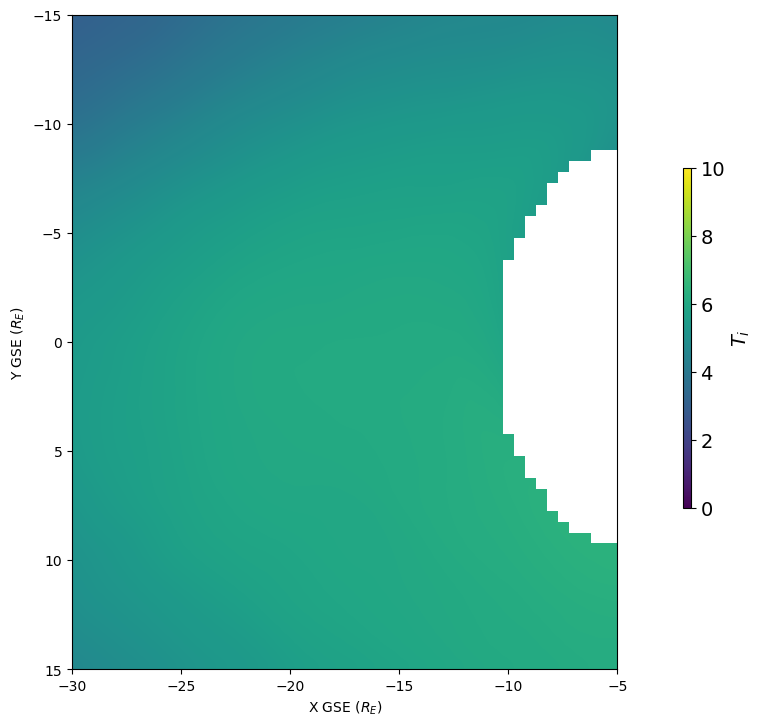

In [6]:
i = -1
fig, ax = plt.subplots(1, 1, figsize = (8.5,8.5))
im = ax.imshow(output_grid[i,:,:,2].T/1000, aspect = 'equal', extent = (x_extent[0], x_extent[1], y_extent[1], y_extent[0]), cmap = 'viridis', vmin = 0, vmax = 10, interpolation = 'gaussian')

ax.set_xlabel(r'X GSE ($R_{E}$)')
ax.set_ylabel(r'Y GSE ($R_{E}$)')
# ax.set_title(r'$B_{Z}=' + str(bz[idx]) + r'$ nT, $V_{X}=' + str(vx[idx]) + r'$ $km/s$')
cbar_ax = fig.add_axes([0.91, 0.3, 0.01, 0.4])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label(r'$T_{i}$', fontsize=14)
cbar.ax.tick_params(labelsize=14)

In [17]:
np.nanmax(output_grid[i,:,:,8].T)

4.717678546905518